# Speech Emotion Recognition: Layer wise Probing of Transformer Models


**Project:** Linguistic-Agnostic SER: A Probing Approach to Acoustic Emotion Encoding

CSCI 535 - Multimodal Probabilistic Learning of Human Communication


**Author:** Chaitanya Parwatkar

This notebook investigates what speech transformer models (wav2vec 2.0 and HuBERT) learn about emotion at each internal layer.

**Method:** For each layer of the model, we extract hidden state representations from audio files, then train a simple logistic regression classifier to predict emotion labels. By comparing classification accuracy across layers, we can see which layers encode the most emotion-relevant information.

**Datasets:** RAVDESS (English) and EmoDB (German)

**Models:** wav2vec 2.0 Base and HuBERT Base

---
## Cell 1: Install Required Packages
Run this cell once. If packages are already installed, it will skip them.

In [1]:
import subprocess
import sys

packages = ['torch', 'transformers', 'librosa', 'scikit-learn', 'numpy', 'pandas', 'matplotlib', 'seaborn', 'tqdm']

for pkg in packages:
    try:
        __import__(pkg if pkg != 'scikit-learn' else 'sklearn')
        print(f'  {pkg} already installed')
    except ImportError:
        print(f'  Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  {pkg} installed successfully')

print('\nAll packages ready!')

  torch already installed
  transformers already installed
  librosa already installed
  scikit-learn already installed
  numpy already installed
  pandas already installed
  matplotlib already installed
  seaborn already installed
  tqdm already installed

All packages ready!


---
## Cell 2: Import Libraries
Load all the libraries we need for the entire notebook.

In [2]:
import os
import numpy as np
import pandas as pd
import json
import re
import torch
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import Wav2Vec2Model, Wav2Vec2Processor, HubertModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Check what device we are running on
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')  # Apple Silicon GPU
    print(f'Using device: MPS (Apple Silicon GPU)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'Using device: CUDA GPU')
else:
    DEVICE = torch.device('cpu')
    print(f'Using device: CPU')

print(f'PyTorch version: {torch.__version__}')

Using device: MPS (Apple Silicon GPU)
PyTorch version: 2.10.0


---
## Cell 3: Configuration
Set all file paths and emotion label mappings here. If you move folders, only change paths here.

In [ ]:
BASE_PATH = '/Users/chaitanyaparwatkar/Desktop/535 Multimodal Project'

# RAVDESS: Use the subfolder to avoid duplicate files
RAVDESS_PATH = os.path.join(BASE_PATH, 'RAVDESS Emotional speech audio', 'audio_speech_actors_01-24')

# EmoDB: All wav files are in a flat directory
EMODB_PATH = os.path.join(BASE_PATH, 'EmoDB Dataset')


# RAVDESS: emotion is the 3rd segment of the filename (split by '-')
RAVDESS_EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# EmoDB: emotion is the 6th character of the filename (index 5)
EMODB_EMOTION_MAP = {
    'W': 'happiness',
    'L': 'boredom',
    'E': 'disgust',
    'A': 'anger',
    'F': 'fear',
    'T': 'sadness',
    'N': 'neutral'
}

# ============================================================
# MODEL NAMES FROM HUGGINGFACE
# ============================================================

WAV2VEC_MODEL_NAME = 'facebook/wav2vec2-base-960h'
HUBERT_MODEL_NAME = 'facebook/hubert-base-ls960'

# ============================================================
# AUDIO SETTINGS
# ============================================================

SAMPLE_RATE = 16000  # Both wav2vec and HuBERT expect 16kHz audio
MAX_AUDIO_LENGTH = 10 * SAMPLE_RATE  # Cap audio at 10 seconds to save memory

# ============================================================
# VERIFY PATHS EXIST
# ============================================================

for name, path in [('RAVDESS', RAVDESS_PATH), ('EmoDB', EMODB_PATH)]:
    if os.path.exists(path):
        print(f'{name} path found: {path}')
    else:
        print(f'WARNING: {name} path NOT found: {path}')
        print(f'  Please check the folder name and update the path above.')

RAVDESS path found: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/RAVDESS Emotional speech audio/audio_speech_actors_01-24
EmoDB path found: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/EmoDB Dataset


---
## Cell 4: Dataset Loading Functions

These functions scan the dataset folders, parse emotion labels from filenames, and load the audio files at 16kHz.

**RAVDESS filename format:** `03-01-05-02-01-02-07.wav` where the 3rd segment (05) = angry

**EmoDB filename format:** `03a01Fa.wav` where the 6th character (F) = fear

In [4]:
def load_ravdess(path, sample_rate=16000, max_length=None):
    """
    Load all RAVDESS audio files and extract emotion labels from filenames.
    Returns a list of dicts with keys: file, label, audio, speaker, gender
    """
    data = []
    skipped = 0
    
    # Walk through each Actor folder
    for actor_folder in sorted(os.listdir(path)):
        actor_path = os.path.join(path, actor_folder)
        if not os.path.isdir(actor_path):
            continue
        
        for fname in sorted(os.listdir(actor_path)):
            if not fname.endswith('.wav'):
                continue
            
            try:
                # Parse filename: modality-channel-emotion-intensity-statement-repetition-actor
                parts = os.path.splitext(fname)[0].split('-')
                emotion_code = parts[2]
                label = RAVDESS_EMOTION_MAP.get(emotion_code, None)
                actor_id = int(parts[6])
                gender = 'male' if actor_id % 2 != 0 else 'female'
                
                if label is None:
                    skipped += 1
                    continue
                
                # Load audio at 16kHz
                filepath = os.path.join(actor_path, fname)
                audio, sr = librosa.load(filepath, sr=sample_rate)
                
                # Trim to max length if specified (saves memory)
                if max_length and len(audio) > max_length:
                    audio = audio[:max_length]
                
                data.append({
                    'file': filepath,
                    'label': label,
                    'audio': audio,
                    'speaker': f'actor_{actor_id:02d}',
                    'gender': gender
                })
            except Exception as e:
                print(f'  Error loading {fname}: {e}')
                skipped += 1
    
    print(f'RAVDESS loaded: {len(data)} files, {skipped} skipped')
    return data


def load_emodb(path, sample_rate=16000, max_length=None):
    """
    Load all EmoDB audio files and extract emotion labels from filenames.
    Returns a list of dicts with keys: file, label, audio, speaker
    """
    data = []
    skipped = 0
    
    for fname in sorted(os.listdir(path)):
        if not fname.endswith('.wav'):
            continue
        
        try:
            # Parse filename: 6th character (index 5) is the emotion code
            emotion_code = os.path.splitext(fname)[0][5]
            label = EMODB_EMOTION_MAP.get(emotion_code, None)
            speaker_id = fname[:2]  # First 2 characters are speaker ID
            
            if label is None:
                skipped += 1
                continue
            
            # Load audio at 16kHz
            filepath = os.path.join(path, fname)
            audio, sr = librosa.load(filepath, sr=sample_rate)
            
            # Trim to max length if specified
            if max_length and len(audio) > max_length:
                audio = audio[:max_length]
            
            data.append({
                'file': filepath,
                'label': label,
                'audio': audio,
                'speaker': f'speaker_{speaker_id}'
            })
        except Exception as e:
            print(f'  Error loading {fname}: {e}')
            skipped += 1
    
    print(f'EmoDB loaded: {len(data)} files, {skipped} skipped')
    return data

---
## Cell 5: Load Both Datasets
This will take about 1-2 minutes as it reads all audio files from disk.

In [5]:
print('Loading RAVDESS dataset...')
ravdess_data = load_ravdess(RAVDESS_PATH, sample_rate=SAMPLE_RATE, max_length=MAX_AUDIO_LENGTH)

print('\nLoading EmoDB dataset...')
emodb_data = load_emodb(EMODB_PATH, sample_rate=SAMPLE_RATE, max_length=MAX_AUDIO_LENGTH)

# Show emotion distribution for both datasets
print('\n--- RAVDESS Emotion Distribution ---')
ravdess_labels = [d['label'] for d in ravdess_data]
for emotion in sorted(set(ravdess_labels)):
    count = ravdess_labels.count(emotion)
    print(f'  {emotion:12s}: {count:4d} files ({count/len(ravdess_labels)*100:.1f}%)')

print(f'\n--- EmoDB Emotion Distribution ---')
emodb_labels = [d['label'] for d in emodb_data]
for emotion in sorted(set(emodb_labels)):
    count = emodb_labels.count(emotion)
    print(f'  {emotion:12s}: {count:4d} files ({count/len(emodb_labels)*100:.1f}%)')

Loading RAVDESS dataset...
RAVDESS loaded: 1440 files, 0 skipped

Loading EmoDB dataset...
EmoDB loaded: 535 files, 0 skipped

--- RAVDESS Emotion Distribution ---
  angry       :  192 files (13.3%)
  calm        :  192 files (13.3%)
  disgust     :  192 files (13.3%)
  fearful     :  192 files (13.3%)
  happy       :  192 files (13.3%)
  neutral     :   96 files (6.7%)
  sad         :  192 files (13.3%)
  surprised   :  192 files (13.3%)

--- EmoDB Emotion Distribution ---
  anger       :   69 files (12.9%)
  boredom     :   81 files (15.1%)
  disgust     :   46 files (8.6%)
  fear        :   71 files (13.3%)
  happiness   :  127 files (23.7%)
  neutral     :   79 files (14.8%)
  sadness     :   62 files (11.6%)


---
## Cell 6: Hidden State Extraction Function

This is the core function. It takes a speech model, feeds audio through it, and extracts the hidden state output from every transformer layer.

**How it works:**
1. Feed raw audio waveform into the model
2. The model processes it through a CNN feature extractor, then through 12 transformer layers
3. We get back 13 hidden states (1 from CNN + 12 from transformer layers)
4. For each hidden state, we average over the time dimension to get a single 768-dimensional vector
5. That vector represents the model's "understanding" of the audio at that layer

In [6]:
def extract_hidden_states(model, processor, audio_data, device, batch_desc='Extracting'):
    """
    Extract hidden states from all layers for a list of audio samples.
    
    Args:
        model: The pretrained speech model (wav2vec2 or HuBERT)
        processor: The model's audio processor
        audio_data: List of dicts, each with 'audio' key containing the waveform
        device: torch device (cpu, mps, or cuda)
        batch_desc: Description for the progress bar
    
    Returns:
        all_hidden_states: numpy array of shape (num_samples, num_layers, hidden_dim)
        labels: list of emotion labels
    """
    model.eval()  # Set model to evaluation mode (no dropout)
    model.to(device)
    
    all_hidden_states = []
    labels = []
    
    with torch.no_grad():  # No gradient computation needed (saves memory)
        for sample in tqdm(audio_data, desc=batch_desc):
            try:
                # Process the audio waveform for the model
                inputs = processor(
                    sample['audio'],
                    sampling_rate=SAMPLE_RATE,
                    return_tensors='pt',
                    padding=True
                )
                input_values = inputs.input_values.to(device)
                
                # Forward pass with hidden states output enabled
                outputs = model(input_values, output_hidden_states=True)
                
                # outputs.hidden_states is a tuple of 13 tensors
                # Each tensor shape: (1, time_steps, 768)
                # We average over time_steps to get one vector per layer
                sample_hidden = []
                for layer_output in outputs.hidden_states:
                    # Average over time dimension (dim=1), move to CPU
                    layer_mean = layer_output.mean(dim=1).squeeze().cpu().numpy()
                    sample_hidden.append(layer_mean)
                
                all_hidden_states.append(sample_hidden)
                labels.append(sample['label'])
                
            except Exception as e:
                print(f'  Error processing {sample["file"]}: {e}')
                continue
    
    # Convert to numpy array: shape (num_samples, num_layers, hidden_dim)
    all_hidden_states = np.array(all_hidden_states)
    
    print(f'Extracted hidden states shape: {all_hidden_states.shape}')
    print(f'  {all_hidden_states.shape[0]} audio files')
    print(f'  {all_hidden_states.shape[1]} layers (1 CNN + {all_hidden_states.shape[1]-1} transformer)')
    print(f'  {all_hidden_states.shape[2]} dimensional vectors')
    
    return all_hidden_states, labels

---
## Cell 7: Probing Function (Logistic Regression per Layer with K-Fold CV)

For each layer, we use **5-Fold Stratified Cross Validation** (more robust than a single train/test split):
1. Split data into 5 folds, keeping emotion distribution balanced
2. For each fold: train on 4 folds, test on 1 fold
3. Average accuracy and F1 across all 5 folds
4. Report mean and standard deviation of accuracy

This methodology follows the K-Fold evaluation approach from the team's base probing pipeline.

In [7]:
def probe_all_layers(hidden_states, labels, n_splits=5, random_state=42):
    """
    Train a logistic regression classifier on each layer's hidden states
    to predict emotion labels using K-Fold Cross Validation.
    
    This approach is more robust than a single train/test split because
    it evaluates the model on multiple different splits and averages the results.
    Inspired by the probing methodology in Nima's base pipeline.
    
    Args:
        hidden_states: numpy array of shape (num_samples, num_layers, hidden_dim)
        labels: list of emotion label strings
        n_splits: number of cross-validation folds (default: 5)
        random_state: random seed for reproducibility
    
    Returns:
        results_df: pandas DataFrame with columns [Layer, Accuracy, Weighted_F1, Std_Accuracy]
    """
    from sklearn.model_selection import StratifiedKFold
    
    num_layers = hidden_states.shape[1]
    results = []
    
    # Convert labels to numpy array
    y = np.array(labels)
    
    print(f'Running {n_splits}-Fold Cross Validation on {len(y)} samples...')
    print(f'Probing {num_layers} layers...\n')
    
    for layer_idx in range(num_layers):
        # Get hidden states for this layer
        X = hidden_states[:, layer_idx, :]  # shape: (num_samples, 768)
        
        # K-Fold Cross Validation
        kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        fold_accuracies = []
        fold_f1s = []
        
        for train_idx, test_idx in kfold.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            # Standardize features (important for logistic regression)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
            
            # Train logistic regression
            clf = LogisticRegression(
                max_iter=1000,
                solver='lbfgs',
                random_state=random_state,
                C=1.0
            )
            clf.fit(X_train, y_train)
            
            # Predict and evaluate
            y_pred = clf.predict(X_test)
            fold_accuracies.append(accuracy_score(y_test, y_pred))
            fold_f1s.append(f1_score(y_test, y_pred, average='weighted'))
        
        # Average across folds
        mean_acc = np.mean(fold_accuracies)
        std_acc = np.std(fold_accuracies)
        mean_f1 = np.mean(fold_f1s)
        
        # Layer name: 0 = CNN output, 1-12 = transformer layers
        layer_name = 'CNN' if layer_idx == 0 else f'Layer {layer_idx}'
        
        results.append({
            'Layer': layer_name,
            'Layer_Num': layer_idx,
            'Accuracy': round(mean_acc, 4),
            'Std_Accuracy': round(std_acc, 4),
            'Weighted_F1': round(mean_f1, 4)
        })
        
        print(f'  {layer_name:10s} | Accuracy: {mean_acc:.4f} (+/- {std_acc:.4f}) | F1: {mean_f1:.4f}')
    
    results_df = pd.DataFrame(results)
    
    # Highlight the best performing layer
    best_layer = results_df.loc[results_df['Accuracy'].idxmax()]
    print(f'\n  BEST LAYER: {best_layer["Layer"]} with Accuracy={best_layer["Accuracy"]:.4f}, F1={best_layer["Weighted_F1"]:.4f}')
    
    return results_df


---
## Cell 8: Visualization Functions
Functions to create plots and tables from the probing results.

In [8]:
def plot_layer_results(results_df, model_name, dataset_name):
    """
    Create a line plot showing accuracy and F1 score across layers.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    
    x = results_df['Layer_Num']
    
    ax.plot(x, results_df['Accuracy'], marker='o', linewidth=2, label='Accuracy', color='#2196F3')
    ax.plot(x, results_df['Weighted_F1'], marker='s', linewidth=2, label='Weighted F1', color='#FF5722')
    
    # Mark the best layer
    best_idx = results_df['Accuracy'].idxmax()
    best_acc = results_df.loc[best_idx, 'Accuracy']
    best_layer = results_df.loc[best_idx, 'Layer_Num']
    ax.annotate(f'Best: {best_acc:.3f}', xy=(best_layer, best_acc),
                xytext=(best_layer + 0.5, best_acc + 0.03),
                fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='black'))
    
    ax.set_xlabel('Layer', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'Emotion Recognition by Layer: {model_name} on {dataset_name}', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['CNN'] + [str(i) for i in range(1, len(x))], fontsize=10)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.0])
    
    plt.tight_layout()
    
    # Save the plot
    save_name = f'probing_{model_name.replace(" ", "_")}_{dataset_name}.png'
    save_path = os.path.join(BASE_PATH, save_name)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Plot saved to: {save_path}')
    
    plt.show()


def plot_comparison(all_results, metric='Accuracy'):
    """
    Compare multiple model/dataset combinations on one plot.
    all_results: dict like {'wav2vec2 RAVDESS': results_df, 'HuBERT RAVDESS': results_df, ...}
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#795548', '#009688']
    markers = ['o', 's', '^', 'D', 'P', 'X']
    
    for i, (name, df) in enumerate(all_results.items()):
        ax.plot(df['Layer_Num'], df[metric], marker=markers[i % len(markers)],
                linewidth=2, label=name, color=colors[i % len(colors)])
    
    ax.set_xlabel('Layer', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'Emotion Recognition {metric} by Layer: All Models and Datasets', fontsize=14, fontweight='bold')
    
    num_layers = list(all_results.values())[0].shape[0]
    ax.set_xticks(range(num_layers))
    ax.set_xticklabels(['CNN'] + [str(i) for i in range(1, num_layers)], fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.0])
    
    plt.tight_layout()
    
    save_path = os.path.join(BASE_PATH, f'comparison_{metric.lower()}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Comparison plot saved to: {save_path}')
    
    plt.show()

---
# EXPERIMENT 1: wav2vec 2.0 on RAVDESS

This is our first experiment. We load the wav2vec 2.0 Base model, extract hidden states from all 13 layers (CNN + 12 transformer), and run emotion classification probing on each layer.

## Cell 9: Load wav2vec 2.0 Model
This downloads the model from HuggingFace (~360 MB). First run takes a few minutes, then it is cached locally.

In [9]:
print('Loading wav2vec 2.0 Base model...')
wav2vec_processor = Wav2Vec2Processor.from_pretrained(WAV2VEC_MODEL_NAME)
wav2vec_model = Wav2Vec2Model.from_pretrained(WAV2VEC_MODEL_NAME)
wav2vec_model.eval()
print('wav2vec 2.0 loaded successfully!')
print(f'Model has {sum(p.numel() for p in wav2vec_model.parameters()):,} parameters')

Loading wav2vec 2.0 Base model...


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


wav2vec 2.0 loaded successfully!
Model has 94,371,712 parameters


## Cell 10: Extract Hidden States (wav2vec 2.0 + RAVDESS)
This processes all 1440 RAVDESS audio files through wav2vec 2.0 and saves the hidden states.

**Expected time: ~20-30 minutes on M5 MacBook**

In [10]:
print('Extracting hidden states: wav2vec 2.0 + RAVDESS')
print('This will take about 20-30 minutes...\n')

wav2vec_ravdess_hidden, wav2vec_ravdess_labels = extract_hidden_states(
    model=wav2vec_model,
    processor=wav2vec_processor,
    audio_data=ravdess_data,
    device=DEVICE,
    batch_desc='wav2vec2 + RAVDESS'
)

# Save to disk so we don't have to re-extract if the notebook crashes
np.save(os.path.join(BASE_PATH, 'wav2vec_ravdess_hidden.npy'), wav2vec_ravdess_hidden)
np.save(os.path.join(BASE_PATH, 'wav2vec_ravdess_labels.npy'), wav2vec_ravdess_labels)
print('\nHidden states saved to disk!')

Extracting hidden states: wav2vec 2.0 + RAVDESS
This will take about 20-30 minutes...



wav2vec2 + RAVDESS: 100%|██████████| 1440/1440 [00:49<00:00, 29.14it/s]


Extracted hidden states shape: (1440, 13, 768)
  1440 audio files
  13 layers (1 CNN + 12 transformer)
  768 dimensional vectors

Hidden states saved to disk!


## Cell 11: Probing Results (wav2vec 2.0 + RAVDESS)
Train logistic regression on each layer and see which layers are best at emotion recognition.

In [11]:
print('=== PROBING: wav2vec 2.0 on RAVDESS ===\n')
results_wav2vec_ravdess = probe_all_layers(wav2vec_ravdess_hidden, wav2vec_ravdess_labels)

print('\n--- Full Results Table ---')
print(results_wav2vec_ravdess[['Layer', 'Accuracy', 'Weighted_F1']].to_string(index=False))

=== PROBING: wav2vec 2.0 on RAVDESS ===

Running 5-Fold Cross Validation on 1440 samples...
Probing 13 layers...

  CNN        | Accuracy: 0.6979 (+/- 0.0201) | F1: 0.6973
  Layer 1    | Accuracy: 0.7819 (+/- 0.0134) | F1: 0.7815
  Layer 2    | Accuracy: 0.8257 (+/- 0.0056) | F1: 0.8250
  Layer 3    | Accuracy: 0.8417 (+/- 0.0174) | F1: 0.8413
  Layer 4    | Accuracy: 0.8618 (+/- 0.0176) | F1: 0.8616
  Layer 5    | Accuracy: 0.8639 (+/- 0.0169) | F1: 0.8634
  Layer 6    | Accuracy: 0.8528 (+/- 0.0131) | F1: 0.8520
  Layer 7    | Accuracy: 0.8306 (+/- 0.0277) | F1: 0.8308
  Layer 8    | Accuracy: 0.7958 (+/- 0.0235) | F1: 0.7962
  Layer 9    | Accuracy: 0.7819 (+/- 0.0406) | F1: 0.7814
  Layer 10   | Accuracy: 0.7542 (+/- 0.0349) | F1: 0.7539
  Layer 11   | Accuracy: 0.6799 (+/- 0.0320) | F1: 0.6776
  Layer 12   | Accuracy: 0.5104 (+/- 0.0356) | F1: 0.5066

  BEST LAYER: Layer 5 with Accuracy=0.8639, F1=0.8634

--- Full Results Table ---
   Layer  Accuracy  Weighted_F1
     CNN    0.697

## Cell 12: Plot Results (wav2vec 2.0 + RAVDESS)

Plot saved to: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/probing_wav2vec2_RAVDESS.png


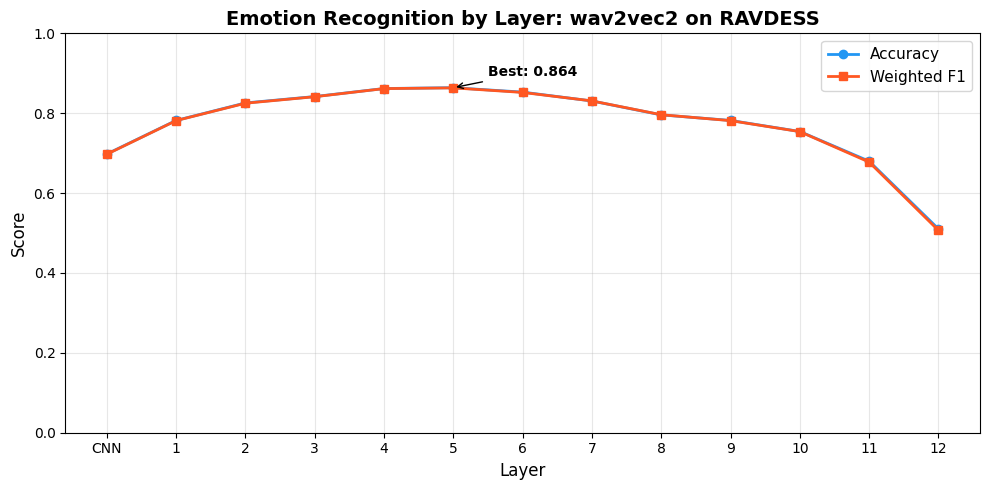

In [12]:
plot_layer_results(results_wav2vec_ravdess, 'wav2vec2', 'RAVDESS')

---
# EXPERIMENT 2: wav2vec 2.0 on EmoDB

Same model, different dataset (German language). This tells us if the layer-wise pattern holds across languages.

## Cell 13: Extract Hidden States (wav2vec 2.0 + EmoDB)
**Expected time: ~5-8 minutes** (EmoDB is much smaller than RAVDESS)

In [13]:
print('Extracting hidden states: wav2vec 2.0 + EmoDB')
print('This will take about 5-8 minutes...\n')

wav2vec_emodb_hidden, wav2vec_emodb_labels = extract_hidden_states(
    model=wav2vec_model,
    processor=wav2vec_processor,
    audio_data=emodb_data,
    device=DEVICE,
    batch_desc='wav2vec2 + EmoDB'
)

# Save to disk
np.save(os.path.join(BASE_PATH, 'wav2vec_emodb_hidden.npy'), wav2vec_emodb_hidden)
np.save(os.path.join(BASE_PATH, 'wav2vec_emodb_labels.npy'), wav2vec_emodb_labels)
print('\nHidden states saved to disk!')

Extracting hidden states: wav2vec 2.0 + EmoDB
This will take about 5-8 minutes...



wav2vec2 + EmoDB: 100%|██████████| 535/535 [00:46<00:00, 11.59it/s]

Extracted hidden states shape: (535, 13, 768)
  535 audio files
  13 layers (1 CNN + 12 transformer)
  768 dimensional vectors

Hidden states saved to disk!


## Cell 14: Probing Results (wav2vec 2.0 + EmoDB)

In [14]:
print('=== PROBING: wav2vec 2.0 on EmoDB ===\n')
results_wav2vec_emodb = probe_all_layers(wav2vec_emodb_hidden, wav2vec_emodb_labels)

print('\n--- Full Results Table ---')
print(results_wav2vec_emodb[['Layer', 'Accuracy', 'Weighted_F1']].to_string(index=False))

=== PROBING: wav2vec 2.0 on EmoDB ===

Running 5-Fold Cross Validation on 535 samples...
Probing 13 layers...

  CNN        | Accuracy: 0.9009 (+/- 0.0305) | F1: 0.9004
  Layer 1    | Accuracy: 0.9495 (+/- 0.0173) | F1: 0.9496
  Layer 2    | Accuracy: 0.9682 (+/- 0.0095) | F1: 0.9680
  Layer 3    | Accuracy: 0.9626 (+/- 0.0132) | F1: 0.9623
  Layer 4    | Accuracy: 0.9720 (+/- 0.0102) | F1: 0.9719
  Layer 5    | Accuracy: 0.9607 (+/- 0.0150) | F1: 0.9605
  Layer 6    | Accuracy: 0.9439 (+/- 0.0118) | F1: 0.9435
  Layer 7    | Accuracy: 0.9028 (+/- 0.0075) | F1: 0.9017
  Layer 8    | Accuracy: 0.8636 (+/- 0.0241) | F1: 0.8611
  Layer 9    | Accuracy: 0.8224 (+/- 0.0251) | F1: 0.8206
  Layer 10   | Accuracy: 0.7664 (+/- 0.0290) | F1: 0.7644
  Layer 11   | Accuracy: 0.7234 (+/- 0.0531) | F1: 0.7225
  Layer 12   | Accuracy: 0.6112 (+/- 0.0610) | F1: 0.6066

  BEST LAYER: Layer 4 with Accuracy=0.9720, F1=0.9719

--- Full Results Table ---
   Layer  Accuracy  Weighted_F1
     CNN    0.9009  

## Cell 15: Plot Results (wav2vec 2.0 + EmoDB)

Plot saved to: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/probing_wav2vec2_EmoDB.png


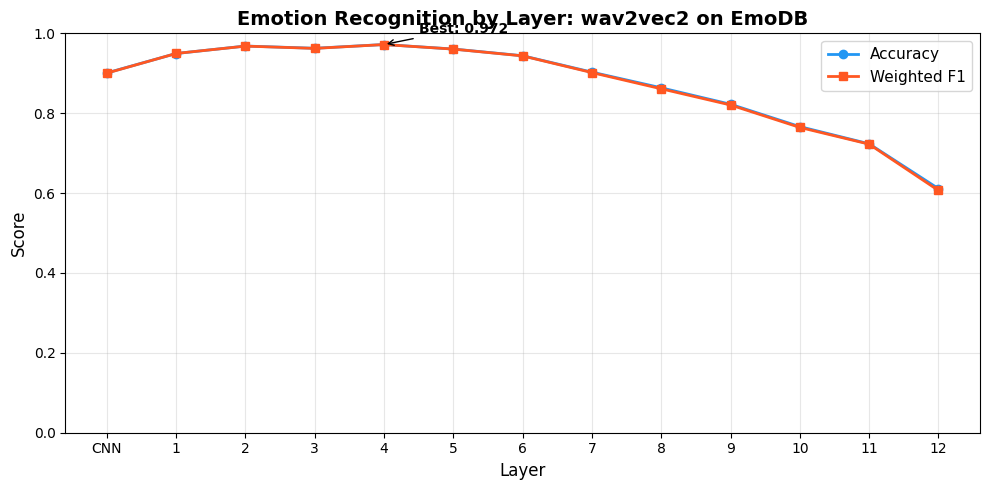

In [15]:
plot_layer_results(results_wav2vec_emodb, 'wav2vec2', 'EmoDB')

---
# EXPERIMENT 3: HuBERT on RAVDESS

Now we switch to the second model: HuBERT Base. Same methodology, same datasets.

**Important:** We first unload wav2vec from memory to free up RAM, then load HuBERT.

## Cell 16: Load HuBERT Model
Free wav2vec memory first, then load HuBERT.

In [16]:
# Free wav2vec from memory to make room for HuBERT
del wav2vec_model
del wav2vec_processor
torch.mps.empty_cache() if torch.backends.mps.is_available() else None
import gc
gc.collect()
print('wav2vec 2.0 unloaded from memory.\n')

# Load HuBERT
# Note: HuBERT uses the same processor as wav2vec 2.0
print('Loading HuBERT Base model...')
hubert_processor = Wav2Vec2Processor.from_pretrained(WAV2VEC_MODEL_NAME)  # Same processor works
hubert_model = HubertModel.from_pretrained(HUBERT_MODEL_NAME)
hubert_model.eval()
print('HuBERT loaded successfully!')
print(f'Model has {sum(p.numel() for p in hubert_model.parameters()):,} parameters')

wav2vec 2.0 unloaded from memory.

Loading HuBERT Base model...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HuBERT loaded successfully!
Model has 94,371,712 parameters


## Cell 17: Extract Hidden States (HuBERT + RAVDESS)
**Expected time: ~20-30 minutes**

In [17]:
print('Extracting hidden states: HuBERT + RAVDESS')
print('This will take about 20-30 minutes...\n')

hubert_ravdess_hidden, hubert_ravdess_labels = extract_hidden_states(
    model=hubert_model,
    processor=hubert_processor,
    audio_data=ravdess_data,
    device=DEVICE,
    batch_desc='HuBERT + RAVDESS'
)

# Save to disk
np.save(os.path.join(BASE_PATH, 'hubert_ravdess_hidden.npy'), hubert_ravdess_hidden)
np.save(os.path.join(BASE_PATH, 'hubert_ravdess_labels.npy'), hubert_ravdess_labels)
print('\nHidden states saved to disk!')

Extracting hidden states: HuBERT + RAVDESS
This will take about 20-30 minutes...



HuBERT + RAVDESS: 100%|██████████| 1440/1440 [00:47<00:00, 30.43it/s]


Extracted hidden states shape: (1440, 13, 768)
  1440 audio files
  13 layers (1 CNN + 12 transformer)
  768 dimensional vectors

Hidden states saved to disk!


## Cell 18: Probing Results (HuBERT + RAVDESS)

In [18]:
print('=== PROBING: HuBERT on RAVDESS ===\n')
results_hubert_ravdess = probe_all_layers(hubert_ravdess_hidden, hubert_ravdess_labels)

print('\n--- Full Results Table ---')
print(results_hubert_ravdess[['Layer', 'Accuracy', 'Weighted_F1']].to_string(index=False))

=== PROBING: HuBERT on RAVDESS ===

Running 5-Fold Cross Validation on 1440 samples...
Probing 13 layers...

  CNN        | Accuracy: 0.7028 (+/- 0.0378) | F1: 0.7021
  Layer 1    | Accuracy: 0.7847 (+/- 0.0345) | F1: 0.7841
  Layer 2    | Accuracy: 0.8174 (+/- 0.0113) | F1: 0.8172
  Layer 3    | Accuracy: 0.8417 (+/- 0.0209) | F1: 0.8409
  Layer 4    | Accuracy: 0.8583 (+/- 0.0210) | F1: 0.8582
  Layer 5    | Accuracy: 0.8660 (+/- 0.0107) | F1: 0.8660
  Layer 6    | Accuracy: 0.8611 (+/- 0.0073) | F1: 0.8607
  Layer 7    | Accuracy: 0.8639 (+/- 0.0194) | F1: 0.8635
  Layer 8    | Accuracy: 0.8472 (+/- 0.0151) | F1: 0.8458
  Layer 9    | Accuracy: 0.8285 (+/- 0.0100) | F1: 0.8268
  Layer 10   | Accuracy: 0.8340 (+/- 0.0221) | F1: 0.8331
  Layer 11   | Accuracy: 0.8340 (+/- 0.0223) | F1: 0.8336
  Layer 12   | Accuracy: 0.8118 (+/- 0.0261) | F1: 0.8114

  BEST LAYER: Layer 5 with Accuracy=0.8660, F1=0.8660

--- Full Results Table ---
   Layer  Accuracy  Weighted_F1
     CNN    0.7028    

## Cell 19: Plot Results (HuBERT + RAVDESS)

Plot saved to: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/probing_HuBERT_RAVDESS.png


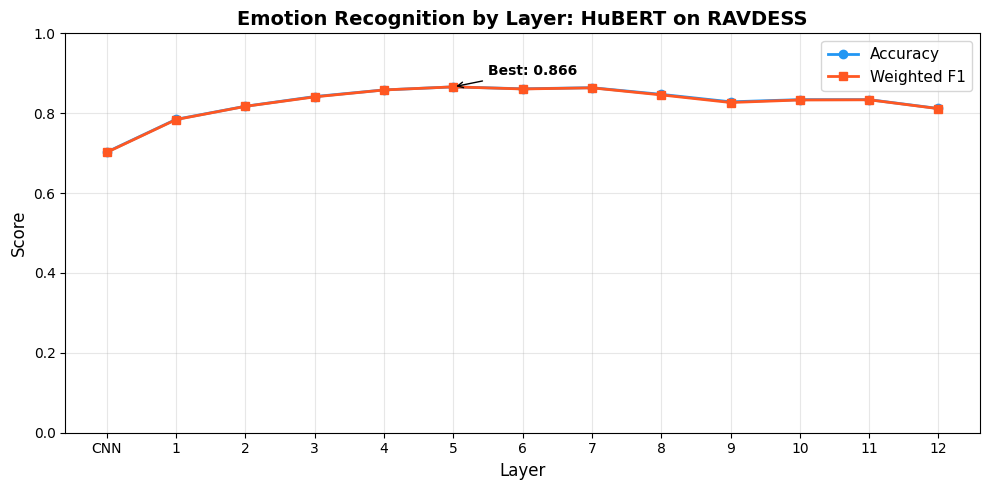

In [19]:
plot_layer_results(results_hubert_ravdess, 'HuBERT', 'RAVDESS')

---
# EXPERIMENT 4: HuBERT on EmoDB

## Cell 20: Extract Hidden States (HuBERT + EmoDB)
**Expected time: ~5-8 minutes**

In [20]:
print('Extracting hidden states: HuBERT + EmoDB')
print('This will take about 5-8 minutes...\n')

hubert_emodb_hidden, hubert_emodb_labels = extract_hidden_states(
    model=hubert_model,
    processor=hubert_processor,
    audio_data=emodb_data,
    device=DEVICE,
    batch_desc='HuBERT + EmoDB'
)

# Save to disk
np.save(os.path.join(BASE_PATH, 'hubert_emodb_hidden.npy'), hubert_emodb_hidden)
np.save(os.path.join(BASE_PATH, 'hubert_emodb_labels.npy'), hubert_emodb_labels)
print('\nHidden states saved to disk!')

Extracting hidden states: HuBERT + EmoDB
This will take about 5-8 minutes...



HuBERT + EmoDB: 100%|██████████| 535/535 [00:14<00:00, 36.65it/s]

Extracted hidden states shape: (535, 13, 768)
  535 audio files
  13 layers (1 CNN + 12 transformer)
  768 dimensional vectors

Hidden states saved to disk!


## Cell 21: Probing Results (HuBERT + EmoDB)

In [21]:
print('=== PROBING: HuBERT on EmoDB ===\n')
results_hubert_emodb = probe_all_layers(hubert_emodb_hidden, hubert_emodb_labels)

print('\n--- Full Results Table ---')
print(results_hubert_emodb[['Layer', 'Accuracy', 'Weighted_F1']].to_string(index=False))

=== PROBING: HuBERT on EmoDB ===

Running 5-Fold Cross Validation on 535 samples...
Probing 13 layers...

  CNN        | Accuracy: 0.8879 (+/- 0.0290) | F1: 0.8867
  Layer 1    | Accuracy: 0.9383 (+/- 0.0183) | F1: 0.9374
  Layer 2    | Accuracy: 0.9514 (+/- 0.0208) | F1: 0.9503
  Layer 3    | Accuracy: 0.9589 (+/- 0.0127) | F1: 0.9585
  Layer 4    | Accuracy: 0.9776 (+/- 0.0152) | F1: 0.9773
  Layer 5    | Accuracy: 0.9776 (+/- 0.0095) | F1: 0.9774
  Layer 6    | Accuracy: 0.9607 (+/- 0.0161) | F1: 0.9602
  Layer 7    | Accuracy: 0.9458 (+/- 0.0150) | F1: 0.9455
  Layer 8    | Accuracy: 0.9271 (+/- 0.0070) | F1: 0.9255
  Layer 9    | Accuracy: 0.9065 (+/- 0.0244) | F1: 0.9046
  Layer 10   | Accuracy: 0.9178 (+/- 0.0247) | F1: 0.9168
  Layer 11   | Accuracy: 0.9308 (+/- 0.0163) | F1: 0.9296
  Layer 12   | Accuracy: 0.9308 (+/- 0.0192) | F1: 0.9302

  BEST LAYER: Layer 4 with Accuracy=0.9776, F1=0.9773

--- Full Results Table ---
   Layer  Accuracy  Weighted_F1
     CNN    0.8879       

## Cell 22 : IEMOCAP Data Loader

In [22]:
import json
import re

IEMOCAP_ROOT = "/Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/IEMOCAP dataset"

with open(os.path.join(IEMOCAP_ROOT, "meta_data", "meta_data.json"), 'r') as f:
    iemocap_meta = json.load(f)

label_map = iemocap_meta['labels']  # {'neu': 0, 'hap': 1, 'ang': 2, 'sad': 3}
print(f"IEMOCAP label mapping: {label_map}")

iemocap_paths = []
iemocap_labels = []
missing_count = 0

for entry in iemocap_meta['meta_data']:
    meta_path = entry['path']  # e.g. Session1/sentences/wav/Ses01F_impro01/Ses01F_impro01_F000.wav
    label = entry['label']
    
    # Extract session number and subfolder/filename
    match = re.match(r'Session(\d)/sentences/wav/(.+)', meta_path)
    if not match:
        missing_count += 1
        continue
    
    session_num = match.group(1)
    remainder = match.group(2)  # Ses01F_impro01/Ses01F_impro01_F000.wav
    
    actual_path = os.path.join(IEMOCAP_ROOT, f"wav-session{session_num}-sentence", remainder)
    
    if os.path.exists(actual_path):
        iemocap_paths.append(actual_path)
        iemocap_labels.append(label)
    else:
        missing_count += 1

print(f"IEMOCAP loaded: {len(iemocap_paths)} files, {missing_count} missing")
print(f"Label distribution:")
from collections import Counter
dist = Counter(iemocap_labels)
for emo, count in sorted(dist.items()):
    print(f"  {emo}: {count}")

IEMOCAP label mapping: {'neu': 0, 'hap': 1, 'ang': 2, 'sad': 3}
IEMOCAP loaded: 5531 files, 0 missing
Label distribution:
  ang: 1103
  hap: 1636
  neu: 1708
  sad: 1084


## Cell 23 : wav2vec 2.0 + IEMOCAP Hidden State Extraction

---
# EXPERIMENT 5: wav2vec 2.0 + IEMOCAP

In [23]:
from transformers import Wav2Vec2Model, Wav2Vec2Processor
from tqdm import tqdm
import gc
import librosa
import numpy as np
import os
import torch

SAMPLE_RATE = globals().get("SAMPLE_RATE", 16000)
MAX_AUDIO_LENGTH = globals().get("MAX_AUDIO_LENGTH", 10 * SAMPLE_RATE)

print("Loading wav2vec 2.0...")
processor_w2v = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model_w2v = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")
model_w2v.eval()

device = globals().get(
    "DEVICE",
    torch.device("mps" if torch.backends.mps.is_available() else "cpu")
)
model_w2v = model_w2v.to(device)

print(f"Extracting hidden states for {len(iemocap_paths)} IEMOCAP files...")

BATCH_SIZE = 2 if torch.backends.mps.is_available() else 8
# Batch size 2 is a safer default on Apple MPS for long clips + hidden states.

all_hidden_iemocap_w2v = []
valid_labels_iemocap = []
batch_audio = []
batch_labels = []

def run_w2v_batch(audio_batch, label_batch):
    inputs = processor_w2v(
        audio_batch,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
        padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.inference_mode():
        outputs = model_w2v(**inputs, output_hidden_states=True)

    batch_hidden = np.stack(
        [layer_output.mean(dim=1).cpu().numpy() for layer_output in outputs.hidden_states],
        axis=1
    )  # shape: (batch, 13, 768)

    all_hidden_iemocap_w2v.extend(batch_hidden)
    valid_labels_iemocap.extend(label_batch)

for fpath, label in tqdm(
    zip(iemocap_paths, iemocap_labels),
    total=len(iemocap_paths),
    desc="wav2vec2 + IEMOCAP"
):
    try:
        speech, _ = librosa.load(fpath, sr=SAMPLE_RATE)

        if len(speech) < 400:
            continue

        if len(speech) > MAX_AUDIO_LENGTH:
            speech = speech[:MAX_AUDIO_LENGTH]

        batch_audio.append(speech)
        batch_labels.append(label)

        if len(batch_audio) == BATCH_SIZE:
            run_w2v_batch(batch_audio, batch_labels)
            batch_audio, batch_labels = [], []

    except Exception as e:
        print(f"  Error on {fpath}: {e}")

if batch_audio:
    run_w2v_batch(batch_audio, batch_labels)

hidden_iemocap_w2v = np.array(all_hidden_iemocap_w2v)
labels_iemocap = np.array(valid_labels_iemocap)

print(f"Shape: {hidden_iemocap_w2v.shape}, Labels: {len(labels_iemocap)}")

np.save(os.path.join(IEMOCAP_ROOT, "wav2vec_iemocap_hidden.npy"), hidden_iemocap_w2v)
np.save(os.path.join(IEMOCAP_ROOT, "wav2vec_iemocap_labels.npy"), labels_iemocap)
print("Saved wav2vec IEMOCAP hidden states.")

del model_w2v, processor_w2v
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()


Loading wav2vec 2.0...


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Extracting hidden states for 5531 IEMOCAP files...


wav2vec2 + IEMOCAP:   2%|▏         | 119/5531 [00:28<21:12,  4.25it/s]

...

  Error on /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/IEMOCAP dataset/wav-session2-sentence/Ses02M_script02_1/Ses02M_script02_1_F011.wav: 


wav2vec2 + IEMOCAP:  99%|█████████▉| 5488/5531 [29:19<00:19,  2.21it/s]

  Error on /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/IEMOCAP dataset/wav-session2-sentence/Ses02M_script03_2/Ses02M_script03_2_F006.wav: 


wav2vec2 + IEMOCAP: 100%|██████████| 5531/5531 [29:51<00:00,  3.09it/s]


Shape: (5460, 13, 768), Labels: 5460
Saved wav2vec IEMOCAP hidden states.


## Cell 24 : wav2vec 2.0 + IEMOCAP Probing

In [24]:
print('=== PROBING: wav2vec 2.0 on IEMOCAP ===\n')
results_wav2vec_iemocap = probe_all_layers(hidden_iemocap_w2v, labels_iemocap)

print('\n--- Full Results Table ---')
print(results_wav2vec_iemocap[['Layer', 'Accuracy', 'Weighted_F1']].to_string(index=False))
print("\nBest layer:", results_wav2vec_iemocap.loc[results_wav2vec_iemocap['Accuracy'].idxmax(), 'Layer'])


=== PROBING: wav2vec 2.0 on IEMOCAP ===

Running 5-Fold Cross Validation on 5460 samples...
Probing 13 layers...

  CNN        | Accuracy: 0.6346 (+/- 0.0124) | F1: 0.6347
  Layer 1    | Accuracy: 0.6291 (+/- 0.0116) | F1: 0.6289
  Layer 2    | Accuracy: 0.6363 (+/- 0.0167) | F1: 0.6359
  Layer 3    | Accuracy: 0.6222 (+/- 0.0150) | F1: 0.6217
  Layer 4    | Accuracy: 0.6093 (+/- 0.0163) | F1: 0.6090
  Layer 5    | Accuracy: 0.6245 (+/- 0.0043) | F1: 0.6240
  Layer 6    | Accuracy: 0.6187 (+/- 0.0095) | F1: 0.6182
  Layer 7    | Accuracy: 0.6147 (+/- 0.0071) | F1: 0.6142
  Layer 8    | Accuracy: 0.5980 (+/- 0.0111) | F1: 0.5974
  Layer 9    | Accuracy: 0.5963 (+/- 0.0090) | F1: 0.5956
  Layer 10   | Accuracy: 0.5993 (+/- 0.0124) | F1: 0.5988
  Layer 11   | Accuracy: 0.5720 (+/- 0.0095) | F1: 0.5714
  Layer 12   | Accuracy: 0.5231 (+/- 0.0040) | F1: 0.5228

  BEST LAYER: Layer 2 with Accuracy=0.6363, F1=0.6359

--- Full Results Table ---
   Layer  Accuracy  Weighted_F1
     CNN    0.634

## Cell 25 : HuBERT + IEMOCAP Hidden State Extraction

In [27]:
from transformers import HubertModel, Wav2Vec2Processor
from tqdm import tqdm
import gc
import librosa
import numpy as np
import os
import torch

SAMPLE_RATE = globals().get("SAMPLE_RATE", 16000)
MAX_AUDIO_LENGTH = globals().get("MAX_AUDIO_LENGTH", 10 * SAMPLE_RATE)

print("Loading HuBERT...")
processor_hub = Wav2Vec2Processor.from_pretrained(globals().get("WAV2VEC_MODEL_NAME", "facebook/wav2vec2-base-960h"))  # Same processor works and avoids the HuBERT tokenizer/protobuf path.
model_hub = HubertModel.from_pretrained("facebook/hubert-base-ls960")
model_hub.eval()

device = globals().get(
    "DEVICE",
    torch.device("mps" if torch.backends.mps.is_available() else "cpu")
)
model_hub = model_hub.to(device)

print(f"Extracting hidden states for {len(iemocap_paths)} IEMOCAP files...")

BATCH_SIZE = 2 if torch.backends.mps.is_available() else 8
# Batch size 2 is a safer default on Apple MPS for long clips + hidden states.

all_hidden_iemocap_hub = []
valid_labels_iemocap_hub = []
batch_audio = []
batch_labels = []

def run_hubert_batch(audio_batch, label_batch):
    inputs = processor_hub(
        audio_batch,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
        padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.inference_mode():
        outputs = model_hub(**inputs, output_hidden_states=True)

    batch_hidden = np.stack(
        [layer_output.mean(dim=1).cpu().numpy() for layer_output in outputs.hidden_states],
        axis=1
    )  # shape: (batch, 13, 768)

    all_hidden_iemocap_hub.extend(batch_hidden)
    valid_labels_iemocap_hub.extend(label_batch)

for fpath, label in tqdm(
    zip(iemocap_paths, iemocap_labels),
    total=len(iemocap_paths),
    desc="HuBERT + IEMOCAP"
):
    try:
        speech, _ = librosa.load(fpath, sr=SAMPLE_RATE)

        if len(speech) < 400:
            continue

        if len(speech) > MAX_AUDIO_LENGTH:
            speech = speech[:MAX_AUDIO_LENGTH]

        batch_audio.append(speech)
        batch_labels.append(label)

        if len(batch_audio) == BATCH_SIZE:
            run_hubert_batch(batch_audio, batch_labels)
            batch_audio, batch_labels = [], []

    except Exception as e:
        print(f"  Error on {fpath}: {e}")

if batch_audio:
    run_hubert_batch(batch_audio, batch_labels)

hidden_iemocap_hub = np.array(all_hidden_iemocap_hub)
labels_iemocap_hub = np.array(valid_labels_iemocap_hub)

print(f"Shape: {hidden_iemocap_hub.shape}, Labels: {len(labels_iemocap_hub)}")

np.save(os.path.join(IEMOCAP_ROOT, "hubert_iemocap_hidden.npy"), hidden_iemocap_hub)
np.save(os.path.join(IEMOCAP_ROOT, "hubert_iemocap_labels.npy"), labels_iemocap_hub)
print("Saved HuBERT IEMOCAP hidden states.")

del model_hub, processor_hub
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()


Loading HuBERT...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Extracting hidden states for 5531 IEMOCAP files...


HuBERT + IEMOCAP:   2%|▏         | 122/5531 [00:09<07:34, 11.90it/s]

  Error on /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/IEMOCAP dataset/wav-session1-sentence/Ses01F_impro04/Ses01F_impro04_M032.wav: 


...

  Error on /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/IEMOCAP dataset/wav-session2-sentence/Ses02M_script02_1/Ses02M_script02_1_F011.wav: 


HuBERT + IEMOCAP:  99%|█████████▉| 5489/5531 [05:23<00:02, 15.36it/s]

  Error on /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/IEMOCAP dataset/wav-session2-sentence/Ses02M_script03_2/Ses02M_script03_2_F006.wav: 


HuBERT + IEMOCAP: 100%|██████████| 5531/5531 [05:25<00:00, 17.01it/s]


Shape: (5460, 13, 768), Labels: 5460
Saved HuBERT IEMOCAP hidden states.


## Cell 26 : HuBERT + IEMOCAP Probing

In [28]:
print('=== PROBING: HuBERT on IEMOCAP ===\n')
results_hubert_iemocap = probe_all_layers(hidden_iemocap_hub, labels_iemocap_hub)

print('\n--- Full Results Table ---')
print(results_hubert_iemocap[['Layer', 'Accuracy', 'Weighted_F1']].to_string(index=False))
print("\nBest layer:", results_hubert_iemocap.loc[results_hubert_iemocap['Accuracy'].idxmax(), 'Layer'])


=== PROBING: HuBERT on IEMOCAP ===

Running 5-Fold Cross Validation on 5460 samples...
Probing 13 layers...

  CNN        | Accuracy: 0.6427 (+/- 0.0111) | F1: 0.6418
  Layer 1    | Accuracy: 0.6480 (+/- 0.0079) | F1: 0.6476
  Layer 2    | Accuracy: 0.6430 (+/- 0.0096) | F1: 0.6427
  Layer 3    | Accuracy: 0.6348 (+/- 0.0221) | F1: 0.6346
  Layer 4    | Accuracy: 0.6401 (+/- 0.0189) | F1: 0.6397
  Layer 5    | Accuracy: 0.6333 (+/- 0.0071) | F1: 0.6329
  Layer 6    | Accuracy: 0.6275 (+/- 0.0159) | F1: 0.6273
  Layer 7    | Accuracy: 0.6280 (+/- 0.0170) | F1: 0.6273
  Layer 8    | Accuracy: 0.6233 (+/- 0.0124) | F1: 0.6228
  Layer 9    | Accuracy: 0.6291 (+/- 0.0138) | F1: 0.6287
  Layer 10   | Accuracy: 0.6322 (+/- 0.0108) | F1: 0.6319
  Layer 11   | Accuracy: 0.6390 (+/- 0.0086) | F1: 0.6385
  Layer 12   | Accuracy: 0.6419 (+/- 0.0166) | F1: 0.6417

  BEST LAYER: Layer 1 with Accuracy=0.6480, F1=0.6476

--- Full Results Table ---
   Layer  Accuracy  Weighted_F1
     CNN    0.6427    

## Cell 27 : Correlation Analysis

In [29]:
from scipy.stats import pearsonr

corr_ravdess, p_ravdess = pearsonr(results_wav2vec_ravdess['Accuracy'], results_hubert_ravdess['Accuracy'])
corr_emodb, p_emodb = pearsonr(results_wav2vec_emodb['Accuracy'], results_hubert_emodb['Accuracy'])
corr_iemocap, p_iemocap = pearsonr(results_wav2vec_iemocap['Accuracy'], results_hubert_iemocap['Accuracy'])

print("wav2vec vs HuBERT layer-wise accuracy correlation:")
print(f"  RAVDESS:  r={corr_ravdess:.3f}, p={p_ravdess:.4f}")
print(f"  EmoDB:    r={corr_emodb:.3f}, p={p_emodb:.4f}")
print(f"  IEMOCAP:  r={corr_iemocap:.3f}, p={p_iemocap:.4f}")

wav2vec vs HuBERT layer-wise accuracy correlation:
  RAVDESS:  r=0.465, p=0.1097
  EmoDB:    r=0.498, p=0.0836
  IEMOCAP:  r=0.018, p=0.9525


## Cell 28: 6 Way Comparison Plot

## Cell 29: Plot Results (HuBERT + EmoDB)

Plot saved to: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/probing_HuBERT_EmoDB.png


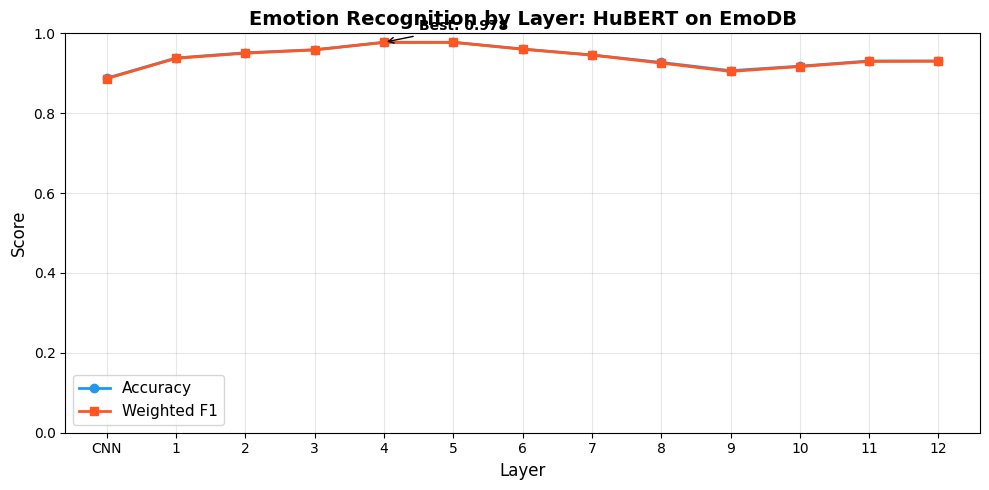

In [30]:
plot_layer_results(results_hubert_emodb, 'HuBERT', 'EmoDB')

---
# FINAL COMPARISON: All Models and Datasets

Now we bring all 4 experiment results together into one comparison plot and one summary table.

## Cell 30: Combined Comparison Plot

Comparison plot saved to: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/comparison_accuracy.png


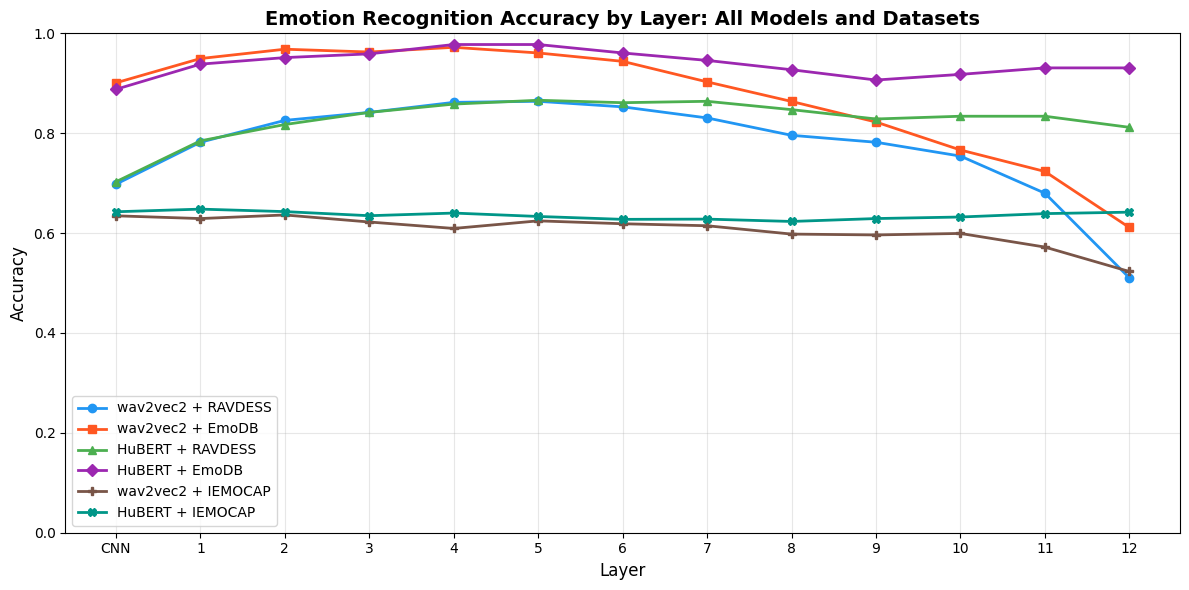

Comparison plot saved to: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/comparison_weighted_f1.png


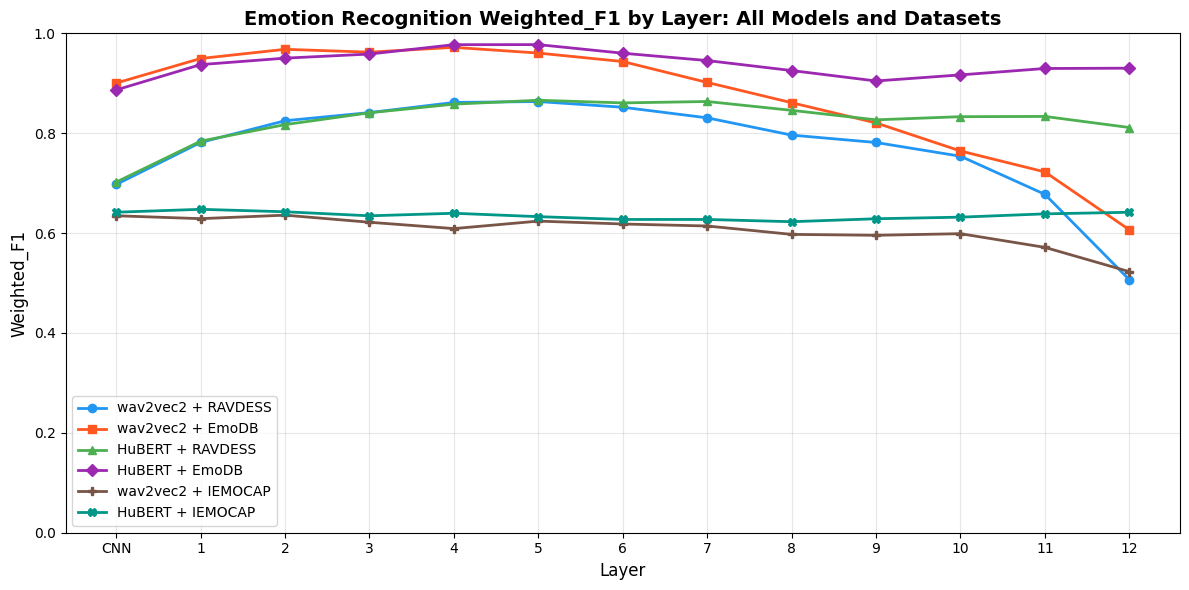

In [31]:
# Collect all results into one dictionary
all_results = {
    'wav2vec2 + RAVDESS': results_wav2vec_ravdess,
    'wav2vec2 + EmoDB': results_wav2vec_emodb,
    'HuBERT + RAVDESS': results_hubert_ravdess,
    'HuBERT + EmoDB': results_hubert_emodb,
    'wav2vec2 + IEMOCAP': results_wav2vec_iemocap,
    'HuBERT + IEMOCAP': results_hubert_iemocap
}

# Plot accuracy comparison
plot_comparison(all_results, metric='Accuracy')

# Plot F1 comparison
plot_comparison(all_results, metric='Weighted_F1')


## Cell 31: Summary Table (Best Layer per Experiment)
This table goes directly into the midterm slides and report.

In [32]:
print('=' * 80)
print('SUMMARY: BEST PERFORMING LAYER PER EXPERIMENT')
print('=' * 80)

summary_rows = []
for name, df in all_results.items():
    best = df.loc[df['Accuracy'].idxmax()]
    summary_rows.append({
        'Experiment': name,
        'Best Layer': best['Layer'],
        'Best Accuracy': best['Accuracy'],
        'Best F1': best['Weighted_F1']
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

print('\n')
print('=' * 80)
print('FULL COMPARISON TABLE: ACCURACY PER LAYER ACROSS ALL EXPERIMENTS')
print('=' * 80)

# Create a wide table: rows = layers, columns = experiments
comparison = pd.DataFrame()
comparison['Layer'] = results_wav2vec_ravdess['Layer']
for name, df in all_results.items():
    comparison[name] = df['Accuracy'].values

print(comparison.to_string(index=False))

# Save comparison table as CSV for the report
csv_path = os.path.join(BASE_PATH, 'probing_results_comparison.csv')
comparison.to_csv(csv_path, index=False)
print(f'\nComparison table saved to: {csv_path}')

SUMMARY: BEST PERFORMING LAYER PER EXPERIMENT
        Experiment Best Layer  Best Accuracy  Best F1
wav2vec2 + RAVDESS    Layer 5         0.8639   0.8634
  wav2vec2 + EmoDB    Layer 4         0.9720   0.9719
  HuBERT + RAVDESS    Layer 5         0.8660   0.8660
    HuBERT + EmoDB    Layer 4         0.9776   0.9773
wav2vec2 + IEMOCAP    Layer 2         0.6363   0.6359
  HuBERT + IEMOCAP    Layer 1         0.6480   0.6476


FULL COMPARISON TABLE: ACCURACY PER LAYER ACROSS ALL EXPERIMENTS
   Layer  wav2vec2 + RAVDESS  wav2vec2 + EmoDB  HuBERT + RAVDESS  HuBERT + EmoDB  wav2vec2 + IEMOCAP  HuBERT + IEMOCAP
     CNN              0.6979            0.9009            0.7028          0.8879              0.6346            0.6427
 Layer 1              0.7819            0.9495            0.7847          0.9383              0.6291            0.6480
 Layer 2              0.8257            0.9682            0.8174          0.9514              0.6363            0.6430
 Layer 3              0.8417     

## Cell 32: Detailed Classification Report (Best Layer)
For the best performing layer on RAVDESS with wav2vec 2.0, show a detailed per-emotion breakdown and confusion matrix.

Detailed analysis for best layer: Layer 5 (wav2vec2 + RAVDESS)

Per-Emotion Classification Report:
              precision    recall  f1-score   support

       angry       0.90      0.92      0.91        38
        calm       0.86      0.84      0.85        38
     disgust       0.94      0.89      0.92        38
     fearful       0.93      0.95      0.94        39
       happy       0.94      0.79      0.86        39
     neutral       0.69      0.95      0.80        19
         sad       0.76      0.76      0.76        38
   surprised       0.90      0.90      0.90        39

    accuracy                           0.87       288
   macro avg       0.87      0.88      0.87       288
weighted avg       0.88      0.87      0.87       288


Confusion matrix saved to: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/confusion_matrix_best_layer.png


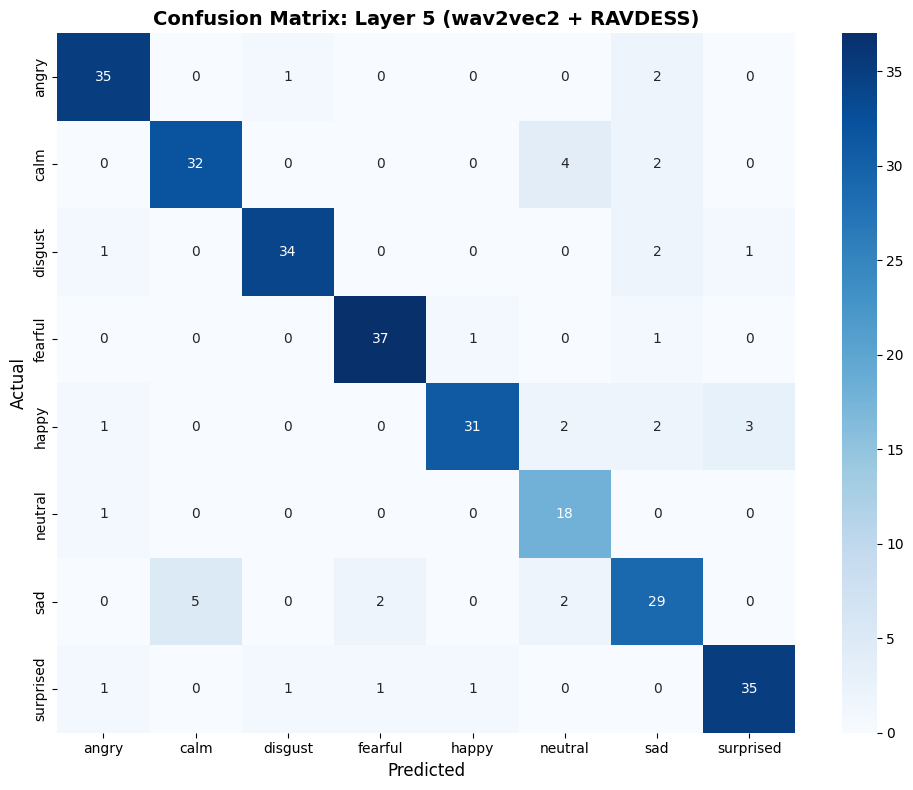

In [33]:
# Find the best layer from wav2vec + RAVDESS
best_layer_idx = results_wav2vec_ravdess['Accuracy'].idxmax()
best_layer_num = results_wav2vec_ravdess.loc[best_layer_idx, 'Layer_Num']
best_layer_name = results_wav2vec_ravdess.loc[best_layer_idx, 'Layer']

print(f'Detailed analysis for best layer: {best_layer_name} (wav2vec2 + RAVDESS)')
print('=' * 60)

# Rerun classification for this specific layer to get detailed metrics
X = wav2vec_ravdess_hidden[:, best_layer_num, :]
y = np.array(wav2vec_ravdess_labels)

train_idx, test_idx = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X[train_idx])
X_test = scaler.transform(X[test_idx])
y_train, y_test = y[train_idx], y[test_idx]

clf = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Per-emotion classification report
print('\nPer-Emotion Classification Report:')
print(classification_report(y_test, y_pred))

# Confusion matrix heatmap
labels_sorted = sorted(set(y_test))
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_sorted, yticklabels=labels_sorted, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix: {best_layer_name} (wav2vec2 + RAVDESS)', fontsize=14, fontweight='bold')
plt.tight_layout()

save_path = os.path.join(BASE_PATH, 'confusion_matrix_best_layer.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'\nConfusion matrix saved to: {save_path}')
plt.show()

---
## Cell 33: Save All Results to Disk
Save everything so teammates can inspect the raw numbers.

In [34]:
# Save individual result tables
for name, df in all_results.items():
    safe_name = name.replace(' ', '_').replace('+', '').replace('__', '_')
    path = os.path.join(BASE_PATH, f'results_{safe_name}.csv')
    df.to_csv(path, index=False)
    print(f'Saved: {path}')

# Save summary
summary_path = os.path.join(BASE_PATH, 'results_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(f'Saved: {summary_path}')

print('\n All results saved! Ready for midterm report and slides.')

Saved: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/results_wav2vec2_RAVDESS.csv
Saved: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/results_wav2vec2_EmoDB.csv
Saved: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/results_HuBERT_RAVDESS.csv
Saved: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/results_HuBERT_EmoDB.csv
Saved: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/results_wav2vec2_IEMOCAP.csv
Saved: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/results_HuBERT_IEMOCAP.csv
Saved: /Users/chaitanyaparwatkar/Desktop/535 Multimodal Project/results_summary.csv

 All results saved! Ready for midterm report and slides.


---
# END OF NOTEBOOK

## What was done in this notebook:

1. Loaded 3 emotion speech datasets: RAVDESS (English, 1440 files, 8 emotions), EmoDB (German, 535 files, 7 emotions), and IEMOCAP (English, 5531 files, 4 emotions)
2. Extracted hidden state representations from all 13 layers (CNN + 12 transformer) of wav2vec 2.0 Base and HuBERT Base
3. Trained logistic regression classifiers per layer to predict emotion labels
4. Compared emotion recognition accuracy across layers, models, and datasets
5. Generated comparison tables, summary CSVs, and evaluation plots

## Key outputs for midterm:
Project folder (`BASE_PATH`):
- `wav2vec_ravdess_hidden.npy`, `wav2vec_ravdess_labels.npy`
- `wav2vec_emodb_hidden.npy`, `wav2vec_emodb_labels.npy`
- `hubert_ravdess_hidden.npy`, `hubert_ravdess_labels.npy`
- `hubert_emodb_hidden.npy`, `hubert_emodb_labels.npy`
- `results_wav2vec2_RAVDESS.csv`
- `results_wav2vec2_EmoDB.csv`
- `results_HuBERT_RAVDESS.csv`
- `results_HuBERT_EmoDB.csv`
- `results_wav2vec2_IEMOCAP.csv`
- `results_HuBERT_IEMOCAP.csv`
- `probing_results_comparison.csv`
- `results_summary.csv`
- `probing_wav2vec2_RAVDESS.png`
- `probing_wav2vec2_EmoDB.png`
- `probing_HuBERT_RAVDESS.png`
- `probing_HuBERT_EmoDB.png`
- `comparison_accuracy.png`
- `comparison_weighted_f1.png`
- `confusion_matrix_best_layer.png`

IEMOCAP folder (`IEMOCAP_ROOT`):
- `wav2vec_iemocap_hidden.npy`, `wav2vec_iemocap_labels.npy`
- `hubert_iemocap_hidden.npy`, `hubert_iemocap_labels.npy`

*Author: Chaitanya Parwatkar  (Modeling and Probing Pipeline)